In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter

In [10]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

In [11]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)
classic=parse('166_Mg_blues.assoc.txt.gz')
covariate=parse('166_Mg_blues_chr5_21394004.assoc.txt.gz')

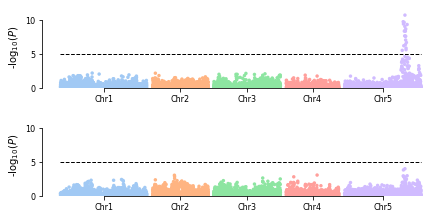

In [12]:
def plotting(dataframe,idx):
    sns.scatterplot(x='position',
                    y='P',
                    data=dataframe,
                    hue='chr',
                    palette='pastel',
                    marker='o',
                    s=12,
                    linewidth=0,
                    legend=False,
                    ax=ax[idx])
    ax[idx].set_xticks([chr1,chr2,chr3,chr4,chr5]),
    ax[idx].tick_params(axis='both', which='major', labelsize=8)
    ax[idx].set_xticklabels(["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
    ax[idx].hlines(y=-np.log10(0.05/len(dataframe)),
                 xmin=min(dataframe['position']),
                 xmax=max(dataframe['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
                 zorder=1)
    ax[idx].set_ylim(0,12)

cm = 1/2.54
fig , ax = plt.subplots(2,1,figsize=(16*cm,8*cm))
plotting(classic,0)
# ax[0].set_title('all SNPs')
plotting(covariate,1)
# ax[1].set_title('with $\itMGR5$ L77fs as covariate')

plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig("FigS9a.pdf", format="pdf",bbox_inches="tight")
plt.savefig("FigS9a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [13]:
significant_SNP=classic[classic['P'] > -np.log10(0.05/len(classic))]
significant_SNP

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
4759,5,5:20319734,20319734,11,A,G,0.155,-169.2313,31.06862,1.668927,1.650040,1.844506e-07,2.916173e-06,5.673193e-05,5.535187,-5.535187,120490580
4773,5,5:20656234,20656234,9,T,A,0.166,-228.5551,29.36752,1.171003,1.148314,7.553945e-13,1.692426e-10,2.465137e-07,9.771490,-9.771490,120827080
4776,5,5:20743393,20743393,14,T,C,0.171,-207.7317,27.51054,1.249202,1.235758,2.851469e-12,3.657746e-10,2.994742e-07,9.436786,-9.436786,120914239
4780,5,5:20859536,20859536,12,G,A,0.104,-202.2775,37.54559,2.293652,2.285104,2.445625e-07,6.014741e-07,7.850611e-06,6.220783,-6.220783,121030382
4785,5,5:21004524,21004524,13,G,G,0.170,-227.2776,29.07069,1.114395,1.092585,6.152074e-13,2.181185e-10,3.797196e-07,9.661307,-9.661307,121175370
4788,5,5:21057767,21057767,14,A,G,0.164,-215.0527,29.69010,1.160780,1.138054,1.619039e-11,4.190220e-09,1.905941e-06,8.377763,-8.377763,121228613
4794,5,5:21182471,21182471,15,C,T,0.166,-204.2840,29.15321,1.127547,1.107070,5.988825e-11,2.095829e-08,7.112796e-06,7.678644,-7.678644,121353317
4797,5,5:21229825,21229825,15,C,T,0.166,-218.2507,28.82106,1.124504,1.105053,2.520719e-12,8.448214e-10,8.034689e-07,9.073235,-9.073235,121400671
4801,5,5:21271637,21271637,12,G,A,0.175,-234.3259,28.57560,1.140754,1.117081,6.597850e-14,1.796790e-11,6.131277e-08,10.745503,-10.745503,121442483
4804,5,5:21314026,21314026,14,G,T,0.171,-211.3586,28.32202,1.039761,1.021222,4.709059e-12,3.405743e-09,3.413215e-06,8.467788,-8.467788,121484872


In [14]:
significant_SNP['P']

4759     5.535187
4773     9.771490
4776     9.436786
4780     6.220783
4785     9.661307
4788     8.377763
4794     7.678644
4797     9.073235
4801    10.745503
4804     8.467788
4808     8.439774
4809     8.368992
4810     6.387845
4815     7.629300
4817     7.621999
4818     7.073093
4824     8.695404
4833     5.632761
4834     5.879933
4840     6.697537
4847     9.359291
Name: P, dtype: float64